<a href="https://colab.research.google.com/github/Smolry/Smart-HSRP-detection/blob/dev/Helmet_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Helmet Detection Using YOLOv8 **
**Dataset**

Source: Indian Helmet Detection Dataset (Kaggle).

Total images: 942.

Format: YOLOv8 annotation format (.txt files with normalized coordinates).

Preprocessing: All images resized to 640×640 (stretch), no augmentation.

**Dataset structure:**

helmet_detection/
├── data.yaml
├── train/
│   ├── images/
│   └── labels/
├── valid/
    ├── images/
    └── labels/


| ID | Name             |
| -- | ---------------- |
| 0  | number_plate     |
| 1  | face_no_helmet   |
| 2  | face_helmet_good |
| 3  | face_helmet_bad  |
| 4  | rider            |


These were updated in data.yaml as:

nc: 5
names: ['number_plate','face_no_helmet','face_helmet_good','face_helmet_bad','rider']

**Training**

Framework: Ultralytics YOLOv8

Base model: yolov8s.pt (pretrained on COCO)

Command (with augmentation):

yolo train \
  model=/content/runs/detect/train3/weights/best.pt \
  data=/content/helmet_detection/data.yaml \
  epochs=150 \
  imgsz=640 \
  lr0=0.002 \
  degrees=10 \
  translate=0.1 \
  scale=0.8 \
  shear=2 \
  perspective=0.0005 \
  fliplr=0.5 \
  flipud=0.1 \
  hsv_h=0.015 \
  hsv_s=0.7 \
  hsv_v=0.4 \
  mosaic=1.0 \
  mixup=0.2 \
  copy_paste=0.2

**Validation **(train4)

| Class            | Precision | Recall | mAP50 | mAP50-95 | Notes                                     |
| ---------------- | --------- | ------ | ----- | -------- | ----------------------------------------- |
| number_plate     | 0.769     | 0.764  | 0.746 | 0.272    | High precision & recall.                  |
| face_no_helmet   | 0.76      | 0.67   | 0.739 | 0.285    | Some missed detections.                   |
| face_helmet_good | 0.743     | 0.803  | 0.768 | 0.357    | Strong recall.                            |
| face_helmet_bad  | 0.373     | 0.283  | 0.31  | 0.161    | Weak detection — under-represented class. |
| rider            | 0.78      | 0.888  | 0.896 | 0.501    | Excellent detection.                      |


Overall metrics:

Precision: 0.685

Recall: 0.682

mAP50: 0.692

mAP50-95: 0.315

Observations:

Model detects riders, helmets, and number plates successfully.

Weak detection for face_helmet_bad due to small dataset size.

Data augmentation improved generalization compared to train3.

Prediction
from ultralytics import YOLO

# Load best model
model = YOLO('/content/runs/detect/train4/weights/best.pt')

# Predict on validation images
model.predict(source='/content/helmet_detection/valid/images', save=True)


Output images stored in: /content/runs/detect/predict/

Shows bounding boxes with class labels for riders, helmets, and number plates.

Capabilities

Detects:

Riders (rider)

Helmets properly worn (face_helmet_good)

Helmets improperly worn (face_helmet_bad)

No helmets (face_no_helmet)

Number plates (number_plate)


In [1]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 28.5 MB/s eta 0:00:00


In [3]:
!unzip helmet_detection.zip -d /content/


Archive:  helmet_detection.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of helmet_detection.zip or
        helmet_detection.zip.zip, and cannot find helmet_detection.zip.ZIP, period.


In [7]:
!unzip /content/helmet_detection.zip -d /content/helmet_detection


Archive:  /content/helmet_detection.zip
   creating: /content/helmet_detection/helmet_detection/
  inflating: /content/helmet_detection/helmet_detection/data.yaml  
   creating: /content/helmet_detection/helmet_detection/train/
   creating: /content/helmet_detection/helmet_detection/train/images/
  inflating: /content/helmet_detection/helmet_detection/train/images/013_105_jpeg.rf.caaf1920c7c7c3877b0ca5e32b5db8c5.jpg  
  inflating: /content/helmet_detection/helmet_detection/train/images/013_106_jpeg.rf.b2f52529bc1b872fc9934c576b3a9be6.jpg  
  inflating: /content/helmet_detection/helmet_detection/train/images/013_108_jpeg.rf.5456c33ffdac986ac240c047955839b7.jpg  
  inflating: /content/helmet_detection/helmet_detection/train/images/013_109_jpeg.rf.8ed635aa8c3f736b0e2d1e0e04eb976f.jpg  
  inflating: /content/helmet_detection/helmet_detection/train/images/013_111_jpeg.rf.f1b84ac4ac812f465a6a3eb8be5d850c.jpg  
  inflating: /content/helmet_detection/helmet_detection/train/images/013_112_jpeg.

In [13]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Summary

model is working, but:

Bounding box precision is weak

Class 3 has low representation → low accuracy

In [20]:
model = YOLO('yolov8s.pt')   # or yolov8n.pt (faster), yolov8m.pt (more accurate)

model.train(
    data='/content/helmet_detection/data.yaml',
    epochs=30,
    imgsz=640,
    batch=16
)

Ultralytics 8.3.226 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/helmet_detection/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7daa83687590>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [33]:
model = YOLO('/content/runs/detect/train3/weights/best.pt')
model.predict(source='/content/helmet_detection/valid/images', save=True)



image 1/142 /content/helmet_detection/valid/images/013_107_jpeg.rf.67e4ab700429b1c3793809d8458d0dd6.jpg: 640x640 1 number_plate, 2 face_no_helmets, 1 face_helmet_good, 1 rider, 16.3ms
image 2/142 /content/helmet_detection/valid/images/013_10_jpeg.rf.89e0e027f1c8e1c4607d526912f6b9b8.jpg: 640x640 1 number_plate, 5 face_no_helmets, 1 rider, 16.2ms
image 3/142 /content/helmet_detection/valid/images/013_110_jpeg.rf.4367b3a40bdcd62436f566d11edd85a6.jpg: 640x640 4 number_plates, 4 face_no_helmets, 2 riders, 15.9ms
image 4/142 /content/helmet_detection/valid/images/013_119_jpeg.rf.da057f7bb46ce31d38a2a8278e75bf16.jpg: 640x640 2 number_plates, 3 face_no_helmets, 2 face_helmet_goods, 1 rider, 15.9ms
image 5/142 /content/helmet_detection/valid/images/013_11_jpeg.rf.b474455049562dcf54debbbd4cd33027.jpg: 640x640 5 number_plates, 6 face_no_helmets, 2 face_helmet_goods, 2 face_helmet_bads, 5 riders, 15.8ms
image 6/142 /content/helmet_detection/valid/images/013_148_jpeg.rf.31e4494343d474e79585af13763

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'number_plate', 1: 'face_no_helmet', 2: 'face_helmet_good', 3: 'face_helmet_bad', 4: 'rider'}
 obb: None
 orig_img: array([[[200, 207, 224],
         [200, 207, 224],
         [200, 207, 224],
         ...,
         [175, 193, 192],
         [176, 194, 193],
         [177, 195, 194]],
 
        [[200, 207, 224],
         [200, 207, 224],
         [200, 207, 224],
         ...,
         [165, 183, 182],
         [166, 184, 183],
         [166, 184, 183]],
 
        [[200, 207, 224],
         [200, 207, 224],
         [200, 207, 224],
         ...,
         [152, 170, 169],
         [152, 170, 169],
         [152, 170, 169]],
 
        ...,
 
        [[ 40,  51,  49],
         [ 62,  73,  71],
         [ 81,  89,  88],
         ...,
         [101, 105, 106],
         [ 79,  83,  84],
         [ 66,  70,  71]],
 
        [[ 34,  47,  45],


# Data augmentation

In [42]:
!yolo train \
  model=/content/runs/detect/train3/weights/best.pt \
  data=/content/helmet_detection/data.yaml \
  epochs=150 \
  imgsz=640 \
  lr0=0.002 \
  degrees=10 \
  translate=0.1 \
  scale=0.8 \
  shear=2 \
  perspective=0.0005 \
  fliplr=0.5 \
  flipud=0.1 \
  hsv_h=0.015 \
  hsv_s=0.7 \
  hsv_v=0.4 \
  mosaic=1.0 \
  mixup=0.2 \
  copy_paste=0.2


Ultralytics 8.3.226 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.2, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/helmet_detection/data.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=/content/runs/detect/train3/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patienc

model is decent (~0.69 mAP50) ✅

Bounding box precision is still low (~0.31 mAP50-95) ⚠️

Main reason = face_helmet_bad class is under-represented ❗

In [46]:
model = YOLO('/content/runs/detect/train4/weights/best.pt')

In [44]:
results = model.val()


Ultralytics 8.3.226 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1525.6±456.4 MB/s, size: 64.4 KB)
val: Scanning /content/helmet_detection/valid/labels.cache... 142 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 142/142 191.6Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.0it/s 4.5s
                   all        142       1064      0.685      0.682      0.692      0.315
          number_plate        117        258      0.769      0.764      0.746      0.272
        face_no_helmet         59        179       0.76       0.67      0.739      0.285
      face_helmet_good        114        274      0.743      0.803      0.768      0.357
       face_helmet_bad         28         53      0.373      0.283       0.31      0.161
                 rider        125      

# Observations per class:
| Class                | Precision | Recall | mAP50 | mAP50-95 | Notes                                                                      |
| -------------------- | --------- | ------ | ----- | -------- | -------------------------------------------------------------------------- |
| **number_plate**     | 0.769     | 0.764  | 0.746 | 0.272    | Pretty good detection, high precision & recall.                            |
| **face_no_helmet**   | 0.76      | 0.67   | 0.739 | 0.285    | Decent precision, recall is a bit lower — some no-helmet faces are missed. |
| **face_helmet_good** | 0.743     | 0.803  | 0.768 | 0.357    | Strong recall, good detection of proper helmets.                           |
| **face_helmet_bad**  | 0.373     | 0.283  | 0.31  | 0.161    | Poor detection — model struggles with improper helmet wearing.             |
| **rider**            | 0.78      | 0.888  | 0.896 | 0.501    | Excellent detection of riders — high precision & recall.                   |


(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

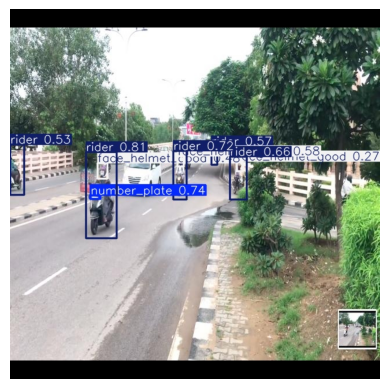

In [48]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('/content/runs/detect/predict/Screenshot-2023-08-02-at-12-27-33-PM_png.rf.1a950cbbe661db30fac5547969a4908a.jpg')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
